# Agent 03 Trades Ticks Monitor and Granular Review

Este notebook separa dos capas:

- `203`: resumen operativo del run y cobertura esperada vs encontrada.
- `206`: anal?tica granular visual por `ticker/date/status`, con foco en `DOWNLOADED_EMPTY`, `SOFT_FAIL`, `HARD_FAIL` y casos sin file.


In [1]:
from pathlib import Path

RUN_ID = 'trades_ticks_prod_2005_2026'
RUN_DIR = Path(r'C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit') / RUN_ID
EXPECTED_CSV = RUN_DIR / 'inputs' / 'tasks_trades_ticks.csv'
TRADES_ROOT = Path(r'D:\trades_ticks_prod_2005_2026')
OHLCV_1M_ROOT = Path(r'D:\ohlcv_1m')
DAILY_ROOT = Path(r'D:\ohlcv_daily')
OUT_DIR = RUN_DIR / 'agent03_trades_ticks_outputs'
SCRIPT_203 = Path(r'C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\203_agent3_monitor_trades_ticks_coverage.py')
SCRIPT_206 = Path(r'C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\206_agent3_trades_ticks_granular_review.py')

INTERVAL_SEC = 15
ONE_SHOT = False

print('RUN_DIR:', RUN_DIR)
print('EXPECTED_CSV exists:', EXPECTED_CSV.exists())
print('TRADES_ROOT exists:', TRADES_ROOT.exists())
print('OHLCV_1M_ROOT exists:', OHLCV_1M_ROOT.exists())
print('DAILY_ROOT exists:', DAILY_ROOT.exists())
print('SCRIPT_203 exists:', SCRIPT_203.exists())
print('SCRIPT_206 exists:', SCRIPT_206.exists())
print('INTERVAL_SEC:', INTERVAL_SEC)


RUN_DIR: C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\trades_ticks_prod_2005_2026
EXPECTED_CSV exists: True
TRADES_ROOT exists: True
OHLCV_1M_ROOT exists: True
DAILY_ROOT exists: True
SCRIPT_203 exists: True
SCRIPT_206 exists: True
INTERVAL_SEC: 15


## Paso 1: Resumen Operativo del Run (203)

Esta capa resume:

- tareas esperadas
- files encontrados
- tareas vac?as (`DOWNLOADED_EMPTY`)
- cola de revisi?n
- hard fails
- cobertura media


In [3]:
# - monitor continuo mientras corre Agent01/02
cmd = f'''python {SCRIPT_203} --run-id {RUN_ID} --run-dir {RUN_DIR} --expected-csv {EXPECTED_CSV} --interval-sec {INTERVAL_SEC}'''
print(cmd)

python C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\203_agent3_monitor_trades_ticks_coverage.py --run-id trades_ticks_prod_2005_2026 --run-dir C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\trades_ticks_prod_2005_2026 --expected-csv C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\trades_ticks_prod_2005_2026\inputs\tasks_trades_ticks.csv --interval-sec 15


In [4]:
# Celda 1: solo tickers observados

from pathlib import Path
import pandas as pd

observed_csv = OUT_DIR / 'observed_status_by_ticker.csv'
print('observed_status_by_ticker.csv', observed_csv.exists())

if observed_csv.exists():
    observed = pd.read_csv(observed_csv)
    observed = observed.sort_values(
        ['review_queue_files', 'hard_fail_files', 'files', 'ticker'],
        ascending=[False, False, False, True]
    )
    display(observed.head(50))

observed_status_by_ticker.csv True


,ticker,files,present_ok_days,hard_fail_files,review_queue_files,expected_days,missing_days_ok,coverage_ratio_ok,observed_flag,ticker_review_status,backtest_ml_ready
0,AAT,3811,3801,10,2961,3959,158,0.960091,True,REVIEW_QUEUE_PENDING,False
1,ACRE,3488,3465,23,2464,3628,163,0.955072,True,REVIEW_QUEUE_PENDING,False
2,ACRS,2621,2621,0,2005,2726,105,0.961482,True,REVIEW_QUEUE_PENDING,False
3,ACTG,2505,2505,0,1868,2602,97,0.962721,True,REVIEW_QUEUE_PENDING,False
4,ADNT,2352,2352,0,1809,2578,226,0.912335,True,REVIEW_QUEUE_PENDING,False
5,AFYA,1672,1672,0,1540,1738,66,0.962025,True,REVIEW_QUEUE_PENDING,False
6,ACET,1680,1680,0,1475,2125,445,0.790588,True,REVIEW_QUEUE_PENDING,False
7,ACIU,2378,2378,0,1450,2471,93,0.962363,True,REVIEW_QUEUE_PENDING,False
8,ADCT,1464,1464,0,1435,1685,221,0.868843,True,REVIEW_QUEUE_PENDING,False
9,ABCL,1318,1318,0,1318,1374,56,0.959243,True,REVIEW_QUEUE_PENDING,False


In [5]:
# Celda 2: filtro por estado semántico

from pathlib import Path
import pandas as pd

coverage_csv = OUT_DIR / 'coverage_by_ticker.csv'
print('coverage_by_ticker.csv', coverage_csv.exists())

if coverage_csv.exists():
    cov = pd.read_csv(coverage_csv)

    print('\n=== NOT_OBSERVED_YET ===')
    display(cov[cov['ticker_review_status'] == 'NOT_OBSERVED_YET'].head(30))

    print('\n=== REVIEW_QUEUE_PENDING ===')
    display(cov[cov['ticker_review_status'] == 'REVIEW_QUEUE_PENDING'].head(30))

    print('\n=== OBSERVED_ACCEPTED ===')
    display(cov[cov['ticker_review_status'] == 'OBSERVED_ACCEPTED'].head(30))

coverage_by_ticker.csv True

=== NOT_OBSERVED_YET ===


,ticker,files,present_ok_days,hard_fail_files,review_queue_files,expected_days,missing_days_ok,coverage_ratio_ok,observed_flag,ticker_review_status,backtest_ml_ready
44,AACI,0,0,0,0,19,19,0.0,False,NOT_OBSERVED_YET,False
45,ABP,0,0,0,0,739,739,0.0,False,NOT_OBSERVED_YET,False
46,AEHL,0,0,0,0,534,534,0.0,False,NOT_OBSERVED_YET,False
47,AENT,0,0,0,0,551,551,0.0,False,NOT_OBSERVED_YET,False
48,AERT,0,0,0,0,537,537,0.0,False,NOT_OBSERVED_YET,False
49,AGAE,0,0,0,0,516,516,0.0,False,NOT_OBSERVED_YET,False
50,AGMH,0,0,0,0,2163,2163,0.0,False,NOT_OBSERVED_YET,False
51,AGRO,0,0,0,0,3950,3950,0.0,False,NOT_OBSERVED_YET,False
52,AHCO,0,0,0,0,504,504,0.0,False,NOT_OBSERVED_YET,False
53,AHMA,0,0,0,0,106,106,0.0,False,NOT_OBSERVED_YET,False



=== REVIEW_QUEUE_PENDING ===


,ticker,files,present_ok_days,hard_fail_files,review_queue_files,expected_days,missing_days_ok,coverage_ratio_ok,observed_flag,ticker_review_status,backtest_ml_ready
0,AAT,3811,3801,10,2961,3959,158,0.960091,True,REVIEW_QUEUE_PENDING,False
1,ACRE,3488,3465,23,2464,3628,163,0.955072,True,REVIEW_QUEUE_PENDING,False
2,ACRS,2621,2621,0,2005,2726,105,0.961482,True,REVIEW_QUEUE_PENDING,False
3,ACTG,2505,2505,0,1868,2602,97,0.962721,True,REVIEW_QUEUE_PENDING,False
4,ADNT,2352,2352,0,1809,2578,226,0.912335,True,REVIEW_QUEUE_PENDING,False
5,AFYA,1672,1672,0,1540,1738,66,0.962025,True,REVIEW_QUEUE_PENDING,False
6,ACET,1680,1680,0,1475,2125,445,0.790588,True,REVIEW_QUEUE_PENDING,False
7,ACIU,2378,2378,0,1450,2471,93,0.962363,True,REVIEW_QUEUE_PENDING,False
8,ADCT,1464,1464,0,1435,1685,221,0.868843,True,REVIEW_QUEUE_PENDING,False
9,ABCL,1318,1318,0,1318,1374,56,0.959243,True,REVIEW_QUEUE_PENDING,False



=== OBSERVED_ACCEPTED ===


,ticker,files,present_ok_days,hard_fail_files,review_queue_files,expected_days,missing_days_ok,coverage_ratio_ok,observed_flag,ticker_review_status,backtest_ml_ready


In [6]:
from pathlib import Path
import pandas as pd

coverage_csv = OUT_DIR / 'coverage_by_ticker.csv'
print('coverage_by_ticker.csv', coverage_csv.exists())

if coverage_csv.exists():
    cov = pd.read_csv(coverage_csv)

    counts = (
        cov.groupby('ticker_review_status', dropna=False)
        .agg(
            tickers=('ticker', 'nunique'),
            files=('files', 'sum'),
            expected_days=('expected_days', 'sum'),
            present_ok_days=('present_ok_days', 'sum'),
            review_queue_files=('review_queue_files', 'sum'),
            hard_fail_files=('hard_fail_files', 'sum'),
        )
        .reset_index()
    )
    counts['pct_tickers'] = 100 * counts['tickers'] / max(counts['tickers'].sum(), 1)
    counts = counts.sort_values(['tickers', 'files'], ascending=[False, False])

    display(counts)

coverage_by_ticker.csv True


,ticker_review_status,tickers,files,expected_days,present_ok_days,review_queue_files,hard_fail_files,pct_tickers
0,NOT_OBSERVED_YET,1918,0,3005680,0,0,0,97.75739
1,REVIEW_QUEUE_PENDING,44,50000,62976,49897,36835,103,2.24261


In [7]:
# tikers esperados de universo vs precesados agente 02  

from pathlib import Path
import json
import pandas as pd

summary_json = OUT_DIR / 'run_summary.json'
coverage_csv = OUT_DIR / 'coverage_by_ticker.csv'
observed_csv = OUT_DIR / 'observed_status_by_ticker.csv'
causes_csv = OUT_DIR / 'causes_by_ticker.csv'
evf_csv = OUT_DIR / 'expected_vs_found_trades_ticks.csv'

for p in [summary_json, coverage_csv, observed_csv, causes_csv, evf_csv]:
    print(p.name, p.exists())

if summary_json.exists():
    print(json.dumps(json.loads(summary_json.read_text(encoding='utf-8')), indent=2, ensure_ascii=False))

if observed_csv.exists():
    print('\n=== observed_status_by_ticker ===')
    display(pd.read_csv(observed_csv).head(20))

if coverage_csv.exists():
    print('\n=== coverage_by_ticker (universo esperado) ===')
    display(pd.read_csv(coverage_csv).head(20))

if causes_csv.exists():
    print('\n=== causes_by_ticker ===')
    display(pd.read_csv(causes_csv).head(20))

if evf_csv.exists():
    print('\n=== expected_vs_found_trades_ticks ===')
    display(pd.read_csv(evf_csv).head(20))


run_summary.json True
coverage_by_ticker.csv True
observed_status_by_ticker.csv True
causes_by_ticker.csv True
expected_vs_found_trades_ticks.csv True
{
  "run_id": "trades_ticks_prod_2005_2026",
  "updated_utc": "2026-03-16T07:57:38.812760+00:00",
  "tickers": 1962,
  "tickers_observed": 44,
  "events_rows_dedup": 50000,
  "review_queue_pending_files": 36835,
  "retry_pending_files": 36835,
  "hard_fail_files": 103,
  "mean_coverage_ok": 0.018981744571232615,
  "gate_status": "REVIEW_QUEUE_OPEN",
  "acceptance_policy": "ACCEPT_ALL_RAW_REVIEW_LATER",
  "raw_dataset_status": "RAW_ACCEPTED_REVIEW_PENDING",
  "review_queue_semantics": "accept_all_raw_then_review_and_redlist",
  "expected_tasks_total": 3068656,
  "expected_tasks_found_files": 401338,
  "expected_tasks_missing_files": 2531656,
  "downloaded_empty_tasks": 135662,
  "download_fail_tasks": 0
}

=== observed_status_by_ticker ===


,ticker,files,present_ok_days,hard_fail_files,review_queue_files,expected_days,missing_days_ok,coverage_ratio_ok,observed_flag,ticker_review_status,backtest_ml_ready
0,AAT,3811,3801,10,2961,3959,158,0.960091,True,REVIEW_QUEUE_PENDING,False
1,ACRE,3488,3465,23,2464,3628,163,0.955072,True,REVIEW_QUEUE_PENDING,False
2,ACRS,2621,2621,0,2005,2726,105,0.961482,True,REVIEW_QUEUE_PENDING,False
3,ACTG,2505,2505,0,1868,2602,97,0.962721,True,REVIEW_QUEUE_PENDING,False
4,ADNT,2352,2352,0,1809,2578,226,0.912335,True,REVIEW_QUEUE_PENDING,False
5,AFYA,1672,1672,0,1540,1738,66,0.962025,True,REVIEW_QUEUE_PENDING,False
6,ACET,1680,1680,0,1475,2125,445,0.790588,True,REVIEW_QUEUE_PENDING,False
7,ACIU,2378,2378,0,1450,2471,93,0.962363,True,REVIEW_QUEUE_PENDING,False
8,ADCT,1464,1464,0,1435,1685,221,0.868843,True,REVIEW_QUEUE_PENDING,False
9,ABCL,1318,1318,0,1318,1374,56,0.959243,True,REVIEW_QUEUE_PENDING,False



=== coverage_by_ticker (universo esperado) ===


,ticker,files,present_ok_days,hard_fail_files,review_queue_files,expected_days,missing_days_ok,coverage_ratio_ok,observed_flag,ticker_review_status,backtest_ml_ready
0,AAT,3811,3801,10,2961,3959,158,0.960091,True,REVIEW_QUEUE_PENDING,False
1,ACRE,3488,3465,23,2464,3628,163,0.955072,True,REVIEW_QUEUE_PENDING,False
2,ACRS,2621,2621,0,2005,2726,105,0.961482,True,REVIEW_QUEUE_PENDING,False
3,ACTG,2505,2505,0,1868,2602,97,0.962721,True,REVIEW_QUEUE_PENDING,False
4,ADNT,2352,2352,0,1809,2578,226,0.912335,True,REVIEW_QUEUE_PENDING,False
5,AFYA,1672,1672,0,1540,1738,66,0.962025,True,REVIEW_QUEUE_PENDING,False
6,ACET,1680,1680,0,1475,2125,445,0.790588,True,REVIEW_QUEUE_PENDING,False
7,ACIU,2378,2378,0,1450,2471,93,0.962363,True,REVIEW_QUEUE_PENDING,False
8,ADCT,1464,1464,0,1435,1685,221,0.868843,True,REVIEW_QUEUE_PENDING,False
9,ABCL,1318,1318,0,1318,1374,56,0.959243,True,REVIEW_QUEUE_PENDING,False



=== causes_by_ticker ===


,ticker,cause,count
0,AAT,duplicates_present_but_under_threshold,2293
1,ACRS,duplicates_present_but_under_threshold,2001
2,ACTG,duplicates_present_but_under_threshold,1859
3,ADNT,duplicates_present_but_under_threshold,1808
4,ACRE,duplicates_present_but_under_threshold,1790
5,AFYA,duplicates_present_but_under_threshold,1540
6,ACET,duplicates_present_but_under_threshold,1470
7,ACIU,duplicates_present_but_under_threshold,1447
8,ADCT,duplicates_present_but_under_threshold,1428
9,ABCL,duplicates_present_but_under_threshold,1294



=== expected_vs_found_trades_ticks ===


C:\Users\AlexJ\AppData\Local\Temp\ipykernel_20572\389703683.py:33: DtypeWarning: Columns (0: download_status, 1: file, 2: severity) have mixed types. Specify dtype option on import or set low_memory=False.
  display(pd.read_csv(evf_csv).head(20))


,task_key,ticker_expected,date_expected,session_expected,download_status,download_rows,found_file_flag,file,severity,expected_ticker_match,expected_date_match,expected_file_outcome
0,AABA|2017-06-16|market,AABA,2017-06-16,market,DOWNLOADED_EMPTY,0.0,False,NaN,NaN,False,False,DOWNLOADED_EMPTY
1,AABA|2017-06-19|market,AABA,2017-06-19,market,DOWNLOADED_OK,137203.0,True,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,SOFT_FAIL,True,True,FOUND_FILE
2,AABA|2017-06-20|market,AABA,2017-06-20,market,DOWNLOADED_OK,84492.0,True,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,SOFT_FAIL,True,True,FOUND_FILE
3,AABA|2017-06-21|market,AABA,2017-06-21,market,DOWNLOADED_OK,86829.0,True,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,SOFT_FAIL,True,True,FOUND_FILE
4,AABA|2017-06-22|market,AABA,2017-06-22,market,DOWNLOADED_OK,63886.0,True,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,SOFT_FAIL,True,True,FOUND_FILE
5,AABA|2017-06-23|market,AABA,2017-06-23,market,DOWNLOADED_OK,60481.0,True,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,SOFT_FAIL,True,True,FOUND_FILE
6,AABA|2017-06-26|market,AABA,2017-06-26,market,DOWNLOADED_OK,98488.0,True,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,SOFT_FAIL,True,True,FOUND_FILE
7,AABA|2017-06-27|market,AABA,2017-06-27,market,DOWNLOADED_OK,70518.0,True,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,SOFT_FAIL,True,True,FOUND_FILE
8,AABA|2017-06-28|market,AABA,2017-06-28,market,DOWNLOADED_OK,68650.0,True,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,SOFT_FAIL,True,True,FOUND_FILE
9,AABA|2017-06-29|market,AABA,2017-06-29,market,DOWNLOADED_OK,75177.0,True,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,SOFT_FAIL,True,True,FOUND_FILE


## Paso 2: Review Granular Visual (206)

Esta capa a?ade informaci?n visual y diagn?stico granular:

- conteo de tareas por estado final
- top tickers por carga de hallazgos
- mapa `ticker x fecha` de estados
- foco espec?fico en `DOWNLOADED_EMPTY`
- explorador interactivo `ticker/date/status`
  - si existe `market.parquet`, dibuja trades intrad?a
  - si no existe y el caso es vac?o, dibuja contexto `daily` alrededor de la fecha


<string>:62: DtypeWarning: Columns (0: download_status, 1: file, 2: severity) have mixed types. Specify dtype option on import or set low_memory=False.


=== TRADES TICKS GRANULAR REVIEW ===
{
  "run_id": "trades_ticks_prod_2005_2026",
  "updated_utc": "2026-03-16T08:13:44.233455+00:00",
  "tickers": 1962,
  "tickers_observed": 44,
  "events_rows_dedup": 50000,
  "review_queue_pending_files": 36835,
  "retry_pending_files": 36835,
  "hard_fail_files": 103,
  "mean_coverage_ok": 0.018981744571232615,
  "gate_status": "REVIEW_QUEUE_OPEN",
  "acceptance_policy": "ACCEPT_ALL_RAW_REVIEW_LATER",
  "raw_dataset_status": "RAW_ACCEPTED_REVIEW_PENDING",
  "review_queue_semantics": "accept_all_raw_then_review_and_redlist",
  "expected_tasks_total": 3068656,
  "expected_tasks_found_files": 403696,
  "expected_tasks_missing_files": 2524856,
  "downloaded_empty_tasks": 140104,
  "download_fail_tasks": 0
}


,final_status,tasks
0,PASS,13165
1,SOFT_FAIL,36732
2,HARD_FAIL,103
3,DOWNLOADED_OK_PENDING_VALIDATION,351532
4,DOWNLOADED_EMPTY,135668
5,DOWNLOAD_FAIL,0
6,EXPECTED_MISSING,2531456


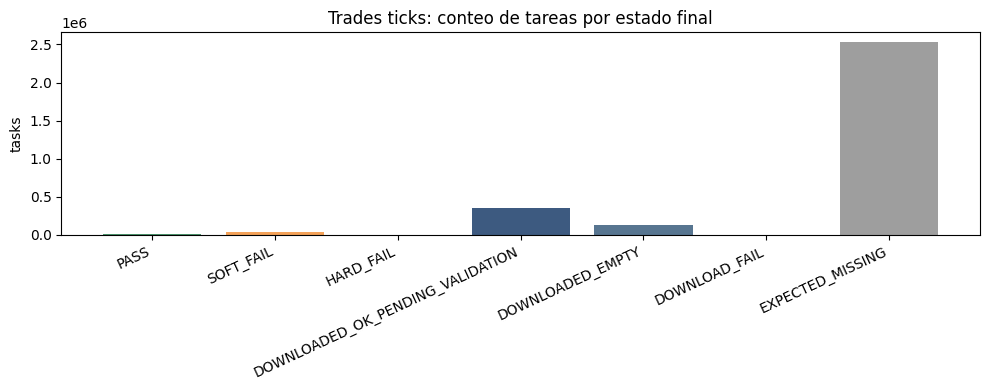

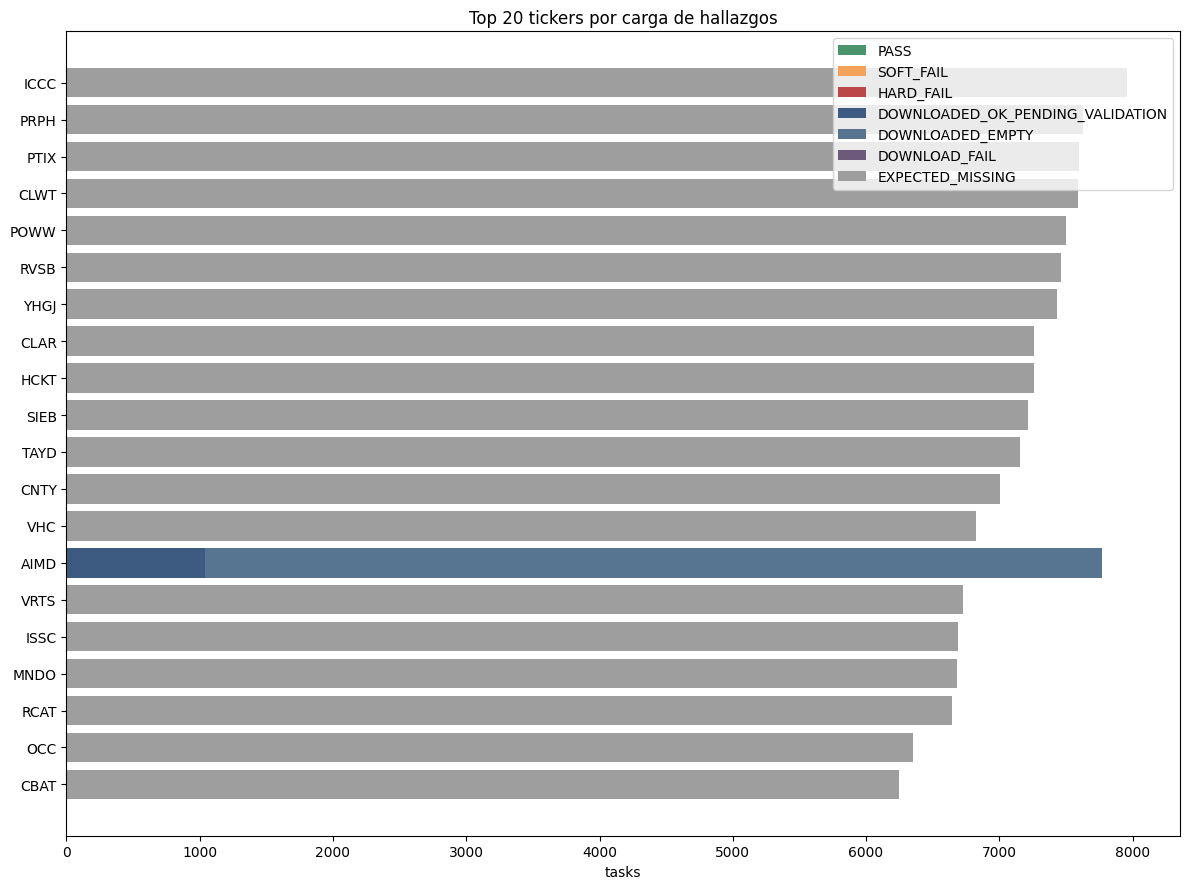

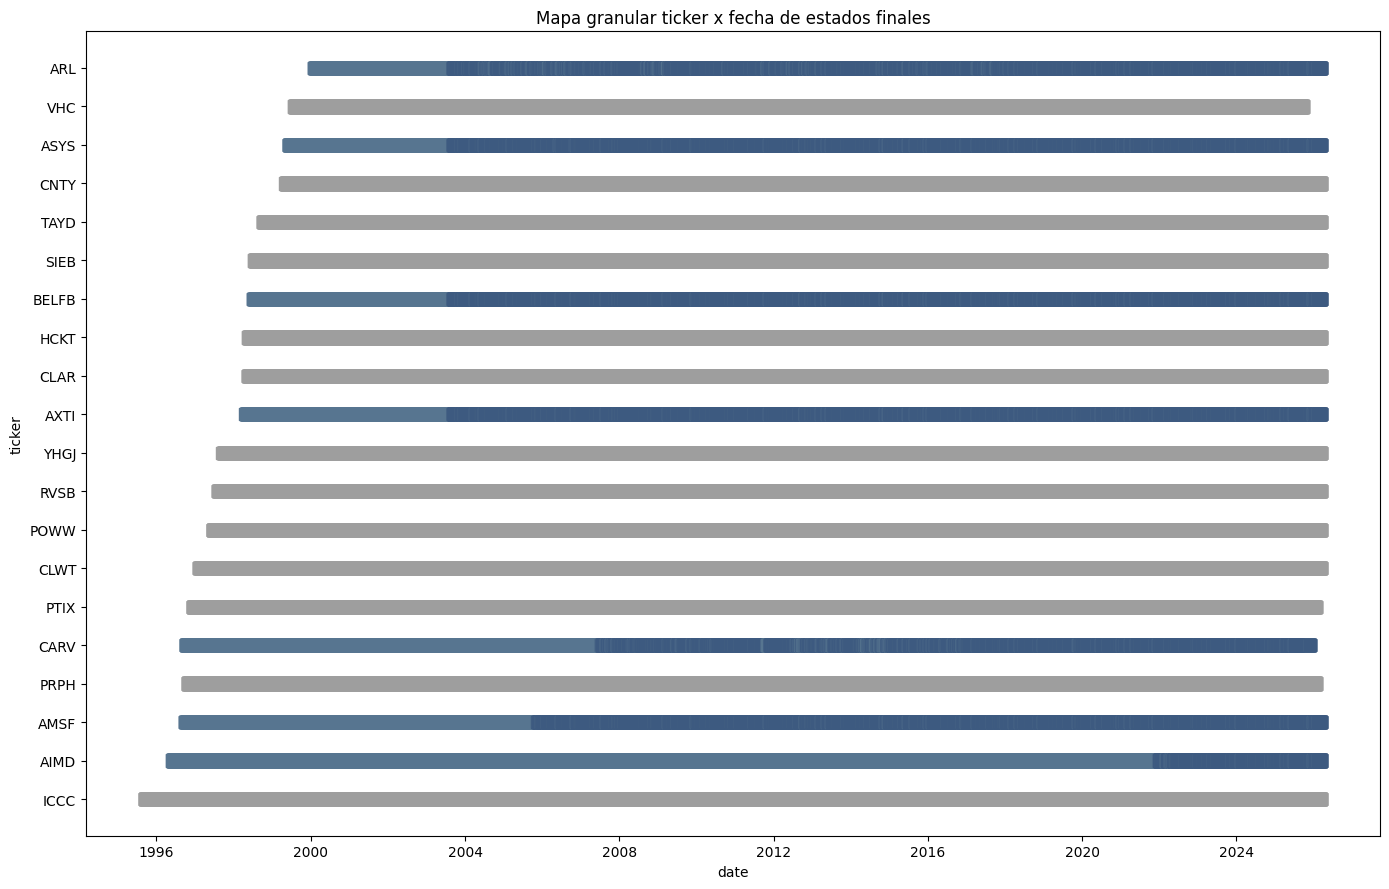

,ticker,empty_tasks,date_min,date_max
0,AIMD,6735,1996-05-30,2026-02-16
1,APYX,3956,2003-11-03,2018-12-31
2,CAPS,3813,1997-03-06,2014-06-24
3,BNC,3773,2011-02-28,2026-02-16
4,BEEM,3264,2008-04-29,2024-03-29
5,CARV,3235,1996-10-04,2025-11-27
6,ADAM,2858,2008-07-04,2021-12-17
7,AVXL,2683,2005-12-06,2026-02-16
8,ACIC,2626,2012-12-10,2026-02-16
9,ABAT,2616,2013-10-17,2026-02-16



=== TOP TICKERS POR PROBLEM RATIO / EMPTY RATIO ===


,ticker,PASS,SOFT_FAIL,HARD_FAIL,DOWNLOADED_OK_PENDING_VALIDATION,DOWNLOADED_EMPTY,DOWNLOAD_FAIL,EXPECTED_MISSING,expected_tasks,found_files,empty_ratio,problem_ratio,pending_validation_ratio
0,CBAT,0,0,0,0,0,0,6251,6251,0,0.0,1.0,0.0
1,CBC,0,0,0,0,0,0,83,83,0,0.0,1.0,0.0
2,CBIO,0,0,0,0,0,0,3224,3224,0,0.0,1.0,0.0
3,CBK,0,0,0,0,0,0,118,118,0,0.0,1.0,0.0
4,CBLL,0,0,0,0,0,0,374,374,0,0.0,1.0,0.0
5,CBRL,0,0,0,0,0,0,2852,2852,0,0.0,1.0,0.0
6,CBUS,0,0,0,0,0,0,2257,2257,0,0.0,1.0,0.0
7,CCCC,0,0,0,0,0,0,1425,1425,0,0.0,1.0,0.0
8,CCG,0,0,0,0,0,0,653,653,0,0.0,1.0,0.0
9,CCHH,0,0,0,0,0,0,122,122,0,0.0,1.0,0.0



=== FECHAS CON MAYOR CONCENTRACION DE HALLAZGOS ===


,date,PASS,SOFT_FAIL,HARD_FAIL,DOWNLOADED_OK_PENDING_VALIDATION,DOWNLOADED_EMPTY,DOWNLOAD_FAIL,EXPECTED_MISSING,problem_tasks
7818,2025-09-01,0,0,0,0,236,0,1204,1440
7881,2025-11-27,0,0,0,0,242,0,1197,1439
7777,2025-07-04,0,0,0,0,237,0,1194,1431
7901,2025-12-25,0,0,0,0,237,0,1192,1429
7906,2026-01-01,0,0,0,0,237,0,1190,1427
7918,2026-01-19,0,0,0,0,238,0,1187,1425
7938,2026-02-16,0,0,0,0,239,0,1186,1425
7766,2025-06-19,0,0,0,0,236,0,1187,1423
7748,2025-05-26,0,0,0,0,233,0,1182,1415
7722,2025-04-18,0,0,0,0,230,0,1170,1400



=== EXPLORADOR GRANULAR POR TICKER / FECHA / ESTADO ===
Objetivo: abrir un caso especifico y ver si el problema es vacio real, fallo de descarga o anomalia intradia leve/fuerte.


In [8]:
TOP_N = 20
CONTEXT_DAYS = 20
MAX_PLOT_POINTS = 50000
FIGSIZE = (12, 4)

exec(SCRIPT_206.read_text(encoding='utf-8'), globals())


## Lectura Recomendada

1. Mira primero `run_summary.json` para separar `found_files` de `downloaded_empty_tasks`.
2. Usa el gr?fico de estados para ver si el run est? dominado por vac?os, soft fails o hard fails.
3. Usa el mapa `ticker x fecha` para detectar si el patr?n es persistente por ticker o puntual por fecha.
4. Abre el explorador y compara:
   - caso con parquet real
   - caso `DOWNLOADED_EMPTY`
   - caso `SOFT_FAIL`

La idea no es solo contar problemas, sino entender visualmente su naturaleza.


In [9]:
from pathlib import Path
import pandas as pd

for name in ['task_status_detail.csv', 'status_by_ticker.csv', 'status_by_date.csv', 'task_causes_detail.csv']:
    p = OUT_DIR / name
    print(name, p.exists())
    if p.exists():
        df = pd.read_csv(p)
        print('rows:', len(df))
        display(df.head(20))


task_status_detail.csv True


C:\Users\AlexJ\AppData\Local\Temp\ipykernel_20572\2278725648.py:8: DtypeWarning: Columns (0: download_status, 1: download_file, 2: download_processed_at_utc, 3: severity, 4: validated_file, 5: issues, 6: warns, 7: validated_processed_at_utc, 8: file_path) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(p)


rows: 3068656


,task_key,ticker,date,session,download_status,download_rows,download_file,download_processed_at_utc,severity,validated_rows,...,validated_processed_at_utc,issues_list,warns_list,file_path,file_exists,final_status,review_queue_flag,hard_fail_flag,empty_flag,pass_ok_flag
0,AABA|2017-06-16|market,AABA,2017-06-16,market,DOWNLOADED_EMPTY,0.0,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,2026-03-14 08:38:45.818068+00:00,NaN,NaN,...,NaN,[],[],D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,False,DOWNLOADED_EMPTY,False,False,True,False
1,AABA|2017-06-19|market,AABA,2017-06-19,market,DOWNLOADED_OK,137203.0,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,2026-03-14 08:40:09.170339+00:00,SOFT_FAIL,137203.0,...,2026-03-16 06:51:04.216982+00:00,[],['duplicates_present_but_under_threshold'],D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,True,SOFT_FAIL,True,False,False,True
2,AABA|2017-06-20|market,AABA,2017-06-20,market,DOWNLOADED_OK,84492.0,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,2026-03-14 08:39:09.779204+00:00,SOFT_FAIL,84492.0,...,2026-03-16 06:51:04.615971+00:00,[],['duplicates_present_but_under_threshold'],D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,True,SOFT_FAIL,True,False,False,True
3,AABA|2017-06-21|market,AABA,2017-06-21,market,DOWNLOADED_OK,86829.0,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,2026-03-14 08:39:23.944935+00:00,SOFT_FAIL,86829.0,...,2026-03-16 06:51:04.871200+00:00,[],['duplicates_present_but_under_threshold'],D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,True,SOFT_FAIL,True,False,False,True
4,AABA|2017-06-22|market,AABA,2017-06-22,market,DOWNLOADED_OK,63886.0,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,2026-03-14 08:39:05.411441+00:00,SOFT_FAIL,63886.0,...,2026-03-16 06:51:05.140099+00:00,[],['duplicates_present_but_under_threshold'],D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,True,SOFT_FAIL,True,False,False,True
5,AABA|2017-06-23|market,AABA,2017-06-23,market,DOWNLOADED_OK,60481.0,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,2026-03-14 08:39:00.054006+00:00,SOFT_FAIL,60481.0,...,2026-03-16 06:51:05.309081+00:00,[],['duplicates_present_but_under_threshold'],D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,True,SOFT_FAIL,True,False,False,True
6,AABA|2017-06-26|market,AABA,2017-06-26,market,DOWNLOADED_OK,98488.0,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,2026-03-14 08:39:33.439815+00:00,SOFT_FAIL,98488.0,...,2026-03-16 06:51:05.471753+00:00,[],['duplicates_present_but_under_threshold'],D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,True,SOFT_FAIL,True,False,False,True
7,AABA|2017-06-27|market,AABA,2017-06-27,market,DOWNLOADED_OK,70518.0,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,2026-03-14 08:39:02.274903+00:00,SOFT_FAIL,70518.0,...,2026-03-16 06:51:05.837656+00:00,[],['duplicates_present_but_under_threshold'],D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,True,SOFT_FAIL,True,False,False,True
8,AABA|2017-06-28|market,AABA,2017-06-28,market,DOWNLOADED_OK,68650.0,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,2026-03-14 08:39:18.633993+00:00,SOFT_FAIL,68650.0,...,2026-03-16 06:51:06.095258+00:00,[],['duplicates_present_but_under_threshold'],D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,True,SOFT_FAIL,True,False,False,True
9,AABA|2017-06-29|market,AABA,2017-06-29,market,DOWNLOADED_OK,75177.0,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,2026-03-14 08:40:04.667255+00:00,SOFT_FAIL,75177.0,...,2026-03-16 06:51:06.323133+00:00,[],['duplicates_present_but_under_threshold'],D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,True,SOFT_FAIL,True,False,False,True


status_by_ticker.csv True
rows: 1962


,ticker,PASS,SOFT_FAIL,HARD_FAIL,DOWNLOADED_OK_PENDING_VALIDATION,DOWNLOADED_EMPTY,DOWNLOAD_FAIL,EXPECTED_MISSING,expected_tasks,found_files,empty_ratio,problem_ratio,pending_validation_ratio
0,CBAT,0,0,0,0,0,0,6251,6251,0,0.0,1.0,0.0
1,CBC,0,0,0,0,0,0,83,83,0,0.0,1.0,0.0
2,CBIO,0,0,0,0,0,0,3224,3224,0,0.0,1.0,0.0
3,CBK,0,0,0,0,0,0,118,118,0,0.0,1.0,0.0
4,CBLL,0,0,0,0,0,0,374,374,0,0.0,1.0,0.0
5,CBRL,0,0,0,0,0,0,2852,2852,0,0.0,1.0,0.0
6,CBUS,0,0,0,0,0,0,2257,2257,0,0.0,1.0,0.0
7,CCCC,0,0,0,0,0,0,1425,1425,0,0.0,1.0,0.0
8,CCG,0,0,0,0,0,0,653,653,0,0.0,1.0,0.0
9,CCHH,0,0,0,0,0,0,122,122,0,0.0,1.0,0.0


status_by_date.csv True
rows: 7958


,date,PASS,SOFT_FAIL,HARD_FAIL,DOWNLOADED_OK_PENDING_VALIDATION,DOWNLOADED_EMPTY,DOWNLOAD_FAIL,EXPECTED_MISSING
0,1995-09-13,0,0,0,0,0,0,1
1,1995-09-14,0,0,0,0,0,0,1
2,1995-09-15,0,0,0,0,0,0,1
3,1995-09-18,0,0,0,0,0,0,1
4,1995-09-19,0,0,0,0,0,0,1
5,1995-09-20,0,0,0,0,0,0,1
6,1995-09-21,0,0,0,0,0,0,1
7,1995-09-22,0,0,0,0,0,0,1
8,1995-09-25,0,0,0,0,0,0,1
9,1995-09-26,0,0,0,0,0,0,1


task_causes_detail.csv True
rows: 36835


,ticker,date,final_status,cause
0,AABA,2017-06-19,SOFT_FAIL,duplicates_present_but_under_threshold
1,AABA,2017-06-20,SOFT_FAIL,duplicates_present_but_under_threshold
2,AABA,2017-06-21,SOFT_FAIL,duplicates_present_but_under_threshold
3,AABA,2017-06-22,SOFT_FAIL,duplicates_present_but_under_threshold
4,AABA,2017-06-23,SOFT_FAIL,duplicates_present_but_under_threshold
5,AABA,2017-06-26,SOFT_FAIL,duplicates_present_but_under_threshold
6,AABA,2017-06-27,SOFT_FAIL,duplicates_present_but_under_threshold
7,AABA,2017-06-28,SOFT_FAIL,duplicates_present_but_under_threshold
8,AABA,2017-06-29,SOFT_FAIL,duplicates_present_but_under_threshold
9,AABA,2017-06-30,SOFT_FAIL,duplicates_present_but_under_threshold
